## Import Libraries

In [5]:
import sys
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.utils.matplotlib_config import register_matplotlib_setconfig
from galform_analysis.analysis.mass_functions import smf_given_redshift_and_subvolume
from galform_analysis.analysis import (
    smfs_given_redshifts_and_subvolume,
    avg_smf_given_redshifts_and_subvolume,
)

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = Path(get_base_dir())
register_matplotlib_setconfig(mpl)
mpl.setconfig()


base_dir = Path('/cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14')

## For a given redshift and sub volume, plot the SMF

In [6]:
example_snapshot = 'iz271'
example_ivol = 0
smf_result = smf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    )

z_val =None # smf_result.get('z')

z_label = f"{z_val:.3f}" if z_val is not None else "n/a"
V_ivol = smf_result.get('V_ivol')
counts = smf_result['counts']
# print(f"Redshift z = {z_val:.3f}",
#     f"Volume V_ivol = {V_ivol:.3e} Mpc^3",
#     f"Total galaxies counted: {counts.sum()}")

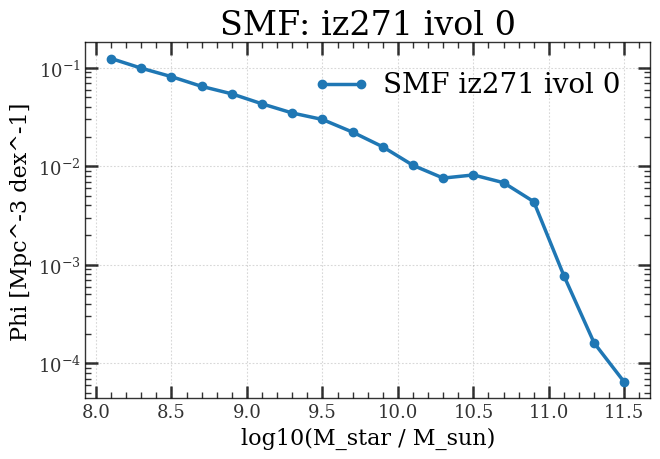

In [7]:
centers = smf_result['centers']
phi = smf_result['phi']
valid = np.isfinite(phi) & (phi > 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF {example_snapshot} ivol {example_ivol}")
ax.set_xlabel("log10(M_star / M_sun)")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title(f"SMF: {example_snapshot} ivol {example_ivol}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## For a given redshift and subvolume, compare to observational SMFs

In [8]:
example_snapshot = 'iz207'
example_ivol = 40
smf_comp_data = smf_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    )

z_val = smf_comp_data.get('z')
V_ivol = smf_comp_data.get('V_ivol')
counts = smf_comp_data['counts']
print(f"Redshift z = {z_val:.3f}",
    f"Volume V_ivol = {V_ivol:.3e} Mpc^3",
    f"Total galaxies counted: {counts.sum()}")

Redshift z = 0.496 Volume V_ivol = 1.556e+05 Mpc^3 Total galaxies counted: 17404


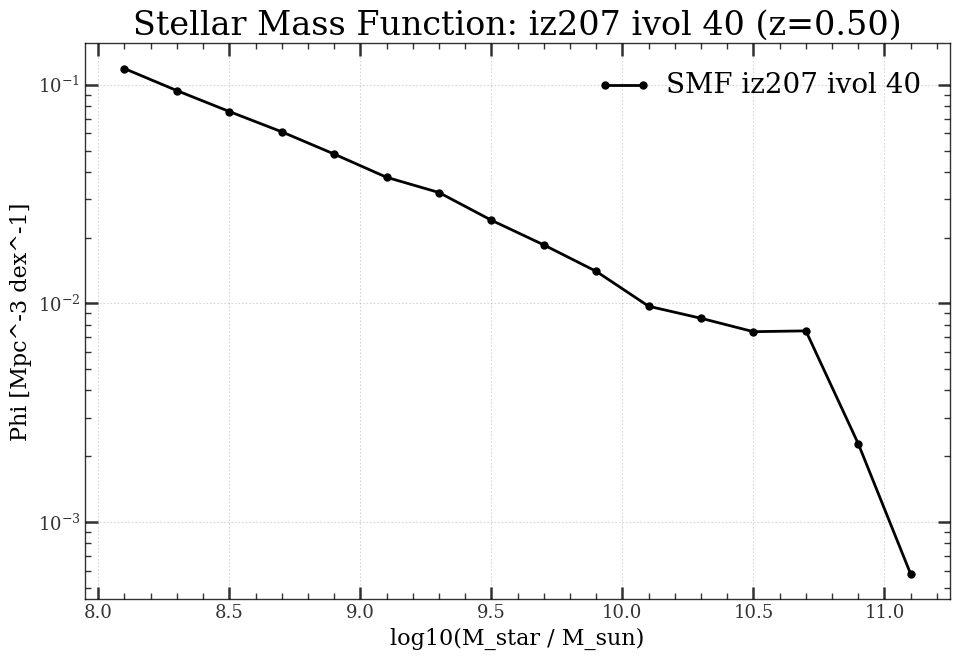

Loaded 22 mass bins Redshift: z = 0.50 Volume: V = 1.56e+05 (Mpc/h)^3


In [9]:
centers = smf_comp_data['centers']
phi = smf_comp_data['phi']
valid = np.isfinite(phi) & (phi > 0)
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF {example_snapshot} ivol {example_ivol}",
        linewidth=2, markersize=5, color='black', zorder=10)
ax.set_xlabel("log10(M_star / M_sun)")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
title = f"Stellar Mass Function: {example_snapshot} ivol {example_ivol}"
z_val = smf_comp_data.get('z')
title += f" (z={z_val:.2f})"
ax.set_title(title)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

V_ivol = smf_comp_data.get('V_ivol')
print(f"Loaded {len(centers)} mass bins",
    f"Redshift: z = {z_val:.2f}",
    f"Volume: V = {V_ivol:.2e} (Mpc/h)^3")

## SMFs for different redshifts

In [10]:
example_ivol = 8
iz_nums = [82, 100, 120, 155]  # subset for faster testing

multi_smf_result = smfs_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    )

smf_df, results_by_z = multi_smf_result
print(f"Loaded {len(results_by_z)} snapshots for ivol={example_ivol}")

Loaded 3 snapshots for ivol=8


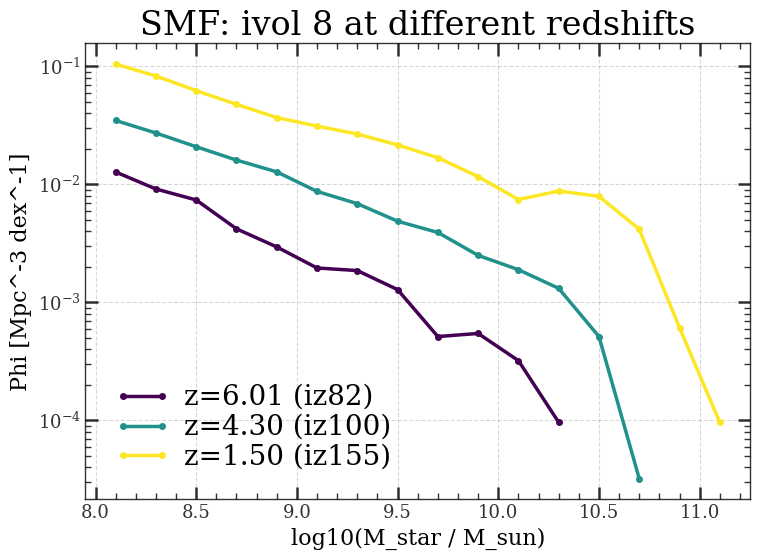

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_yscale('log')
colors = plt.cm.viridis(np.linspace(0, 1, len(results_by_z)))
for res, color in zip(results_by_z, colors):
    centers = res['centers']
    phi = res['phi']
    valid = np.isfinite(phi) & (phi > 0)
    ax.plot(centers[valid], phi[valid], 'o-', label=f"z={res['z']:.2f} ({res['iz']})", color=color, markersize=4)
ax.set_xlabel("log10(M_star / M_sun)")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title(f"SMF: ivol {example_ivol} at different redshifts")
ax.grid(alpha=0.3, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

## For a given sub volume average over given redshifts

In [12]:
example_ivol = 1  # choose a subvolume
iz_nums = [82, 100, 120, 155, 207]  # snapshots that exist in base_dir

avg_smf_result = avg_smf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    )

print(f"Successfully used {avg_smf_result['n_used']}/{avg_smf_result['n_requested']} snapshots",
    f"Snapshots: {avg_smf_result['iz_list']}",
    f"Redshifts: {[f'{z:.2f}' for z in avg_smf_result['z_list']]}")

Successfully used 4/5 snapshots Snapshots: ['iz82', 'iz120', 'iz155', 'iz207'] Redshifts: ['6.01', '3.05', '1.50', '0.50']


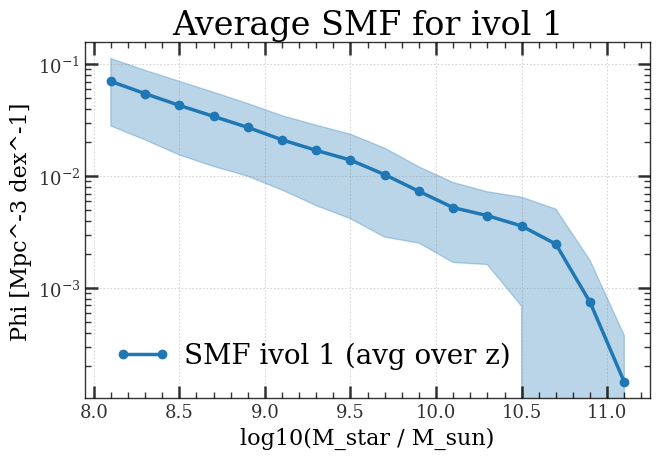

In [13]:
centers = avg_smf_result['centers']
phi = avg_smf_result['phi']
phi_std = avg_smf_result['phi_std']
valid = np.isfinite(phi) & (phi > 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale('log')
ax.plot(centers[valid], phi[valid], 'o-', label=f"SMF ivol {avg_smf_result['ivol']} (avg over z)", color='C0')
ax.fill_between(centers[valid], (phi - phi_std)[valid], (phi + phi_std)[valid], alpha=0.3, color='C0')
ax.set_xlabel("log10(M_star / M_sun)")
ax.set_ylabel("Phi [Mpc^-3 dex^-1]")
ax.set_title(f"Average SMF for ivol {avg_smf_result['ivol']}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()